# **DeepFER: Facial Emotion Recognition Using CNN**

## Overview :
DeepFER: Facial Emotion Recognition Using Deep Learning aims to develop a robust and efficient system for recognizing emotions from facial expressions using advanced deep learning techniques. This project leverages Convolutional Neural Networks (CNNs) and Transfer Learning to accurately classify emotions such as happiness, sadness, anger, surprise, and more from images of human faces. The system will be trained on a diverse dataset of facial images, employing data augmentation and fine-tuning methods to enhance its performance. By integrating state-of-the-art computer vision algorithms and neural network architectures, DeepFER seeks to achieve high accuracy and real-time processing capabilities. The ultimate goal is to create a versatile tool that can be applied in various fields, including human-computer interaction, mental health monitoring, and customer service, enhancing the way machines understand and respond to human emotions.

# **GitHub** : https://github.com/Tapomay1/Facial-Emotion-Recognition-Using-CNN

## Project Background :
Customer satisfaction in the e-commerce sector is a pivotal metric that influences loyalty, repeat business, and word-of-mouth marketing. Traditionally, companies have relied on direct surveys to gauge customer satisfaction, which can be time-consuming and may not always capture the full spectrum of customer experiences. With the advent of deep learning, it's now possible to predict customer satisfaction scores in real-time, offering a granular view of service performance and identifying areas for immediate improvement.

In recent years, the field of facial emotion recognition has gained significant attention due to its wide range of applications in various domains, including mental health monitoring, human-computer interaction, customer service, and security. Emotion recognition from facial expressions is a challenging task, as it involves accurately identifying subtle differences in facial features corresponding to different emotional states. Traditional methods relied heavily on handcrafted features and rule-based approaches, which often lacked the ability to generalize across diverse datasets and real-world scenarios.

The advent of deep learning, particularly Convolutional Neural Networks (CNNs), has revolutionized the way facial emotion recognition systems are developed. CNNs have demonstrated exceptional performance in image classification tasks by automatically learning hierarchical feature representations from raw data.

This project, DeepFER: Facial Emotion Recognition Using Deep Learning, aims to harness the power of CNNs and Transfer Learning to build a robust and efficient facial emotion recognition system. By training the model on large, annotated datasets and employing advanced techniques such as data augmentation and fine-tuning, DeepFER aspires to achieve high accuracy and real-time processing capabilities.

The motivation behind this project stems from the growing need for automated systems that can understand and respond to human emotions effectively. Such systems can significantly enhance user experiences in various applications, from interactive virtual assistants to personalized mental health interventions. DeepFER seeks to bridge the gap between advanced AI techniques and practical emotion recognition applications, paving the way for more intuitive and empathetic machine interactions with humans.

## Project Goal :
The primary goal of DeepFER: Facial Emotion Recognition Using Deep Learning is to develop an advanced and efficient system capable of accurately identifying and classifying human emotions from facial expressions in real-time. By leveraging state-of-the-art Convolutional Neural Networks (CNNs) and Transfer Learning techniques, this project aims to create a robust model that can handle the inherent variability in facial expressions and diverse image conditions. The system will be trained on a comprehensive dataset featuring seven distinct emotions: angry, sad, happy, fear, neutral, disgust, and surprise. The ultimate objective is to achieve high accuracy and reliability, making DeepFER suitable for applications in human-computer interaction, mental health monitoring, customer service, and beyond. Through this project, we aim to bridge the gap between cutting-edge AI research and practical emotion recognition applications, contributing to more empathetic and responsive machine interactions with humans.

## Dataset Composition :
Contains images categorized into seven distinct emotion classes: angry, sad, happy, fear, neutral, disgust, and surprise.
## Emotion Classes :
Angry: Images depicting expressions of anger.

Sad: Images depicting expressions of sadness.

Happy: Images depicting expressions of happiness.

Fear: Images depicting expressions of fear.

Neutral: Images depicting neutral, non-expressive faces.

Disgust: Images depicting expressions of disgust.

Surprise: Images depicting expressions of surprise.

In [3]:
!pip install tensorflow

In [2]:
# -----------------------------
# Core system and file handling libraries
# -----------------------------
import os
import zipfile

# -----------------------------
# Numerical computation and data handling
# -----------------------------
import numpy as np
import pandas as pd

# -----------------------------
# Image processing and visualization
# -----------------------------
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import PIL

# -----------------------------
# Deep learning framework
# -----------------------------
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# -----------------------------
# CNN layers and regularization components
# -----------------------------
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

# -----------------------------
# Data preprocessing and model utilities
# -----------------------------
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split


In [ ]:
# # extracting data from zipfile

# import zipfile
# import os

# dataset_path = "/content/drive/MyDrive/MS : Data Science & AI/05 - DeepFER: Facial Emotion Recognition Using Deep Learning/Face Emotion Recognition Dataset.zip"
# extract_path = "/content/drive/MyDrive/MS : Data Science & AI/05 - DeepFER: Facial Emotion Recognition Using Deep Learning/dataset"

# with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("Dataset extracted successfully!")

Dataset extracted successfully!


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# dataset path
data_dir = "/content/drive/MyDrive/Colab Notebooks/SPECIALIZATION MS PROJECTS/Module - 5/Dataset/images"

In [10]:
# Defining paths for tran and val images
train_dir = "/content/drive/MyDrive/Colab Notebooks/SPECIALIZATION MS PROJECTS/Module - 5/Dataset/images/images/train"
val_dir = "/content/drive/MyDrive/Colab Notebooks/SPECIALIZATION MS PROJECTS/Module - 5/Dataset/images/images/validation"

Classes = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
img_size = 224
batch_size = 32

In [11]:
# Dataset Directory
data_dir = train_dir

In [12]:
# List of all Classes
import os
sub_folders = os.listdir(data_dir)
sub_folders

# Declaring the lists for images and labels
images = []
labels = []

In [13]:
# Iterate through each category folder to extract images and labels
for sub_folder in sub_folders:
    label = sub_folder

    # Create full directory path for the current category
    path = os.path.join(data_dir, sub_folder)

    # Retrieve all image file names inside the category folder
    sub_folder_images = os.listdir(path)

    # Process each image file
    for image_name in sub_folder_images:
        # Build the complete file path for the image
        image_path = os.path.join(path, image_name)

        # Load image in grayscale format using OpenCV
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        # Store image data and its corresponding label
        images.append(img)
        labels.append(label)


In [14]:
# Transform image and label collections into NumPy arrays
images = np.array(images)
labels = np.array(labels)

# Verify total number of loaded images
print(len(images))


8846


### Dataset Partitioning Strategy

The dataset is systematically separated into training, validation, and testing subsets using the train_test_split utility from the scikit-learn library.

* Training set (X_train, y_train): Used to train the model and learn underlying patterns.

* Validation set (X_val, y_val): Utilized during model tuning to monitor performance and prevent overfitting.

* Test set (X_test, y_test): Reserved for final performance evaluation on unseen data.


Initially, 20% of the data is held out as the test set. From the remaining data, 10% is further allocated for validation. A fixed random_state is applied to maintain consistency and reproducibility across multiple runs.

In [15]:
# Divide the dataset into training, validation, and testing subsets

# Step 1: Separate a portion of data for final testing
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42
)

# Step 2: Further split training data to create a validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)


### Image Preprocessing Pipeline

* A custom preprocessing function is designed to transform raw image data into a format suitable for the neural network.

* The function performs the following operations:

* Pixel normalization: Image pixel values are scaled by dividing by 255.0, converting them to a standardized range between 0 and 1.

* Image resizing: Each image is resized to a uniform resolution of 48 × 48 pixels using OpenCV’s resize method, ensuring consistent input dimensions.

Data reshaping: The processed images are reshaped to match the neural network’s required input structure
(batch_size, height, width, channels).
Here, batch_size is set to -1 to support flexible batch sizes, and channels is set to 1 since the images are grayscale.

In [16]:
# Prepare image data for model input
def preprocessing(img):
    # Scale pixel intensities to a 0–1 range
    img = img / 255.0

    # Standardize image dimensions
    img = cv2.resize(img, (48, 48))

    # Adjust shape to match the model's expected input format
    return img.reshape(-1, 48, 48, 1)




### Applying Preprocessing to Dataset Splits

The preprocessing step is executed on the **training**, **validation**, and **testing** datasets by applying the `preprocessing` function to each image using Python’s `map` utility. After processing, the outputs are converted into NumPy arrays for efficient computation.

Key steps involved:

* **`map(preprocessing, X_train)`**: Iterates over each image in the training set and applies the preprocessing function.
* **`list(map(...))`**: Materializes the processed images into a list structure.
* **`np.array(...)`**: Converts the list into a NumPy array, enabling compatibility with deep learning workflows.


In [17]:
# Execute preprocessing on all dataset partitions

# Process training samples
X_train = np.array(list(map(preprocessing, X_train)))

# Process validation samples
X_val = np.array(list(map(preprocessing, X_val)))

# Process testing samples
X_test = np.array(list(map(preprocessing, X_test)))


The code reshapes the input data arrays to eliminate an unnecessary dimension. The neural network model expects input in the shape `(batch_size, height, width, channels)`, where `batch_size` denotes the number of samples per batch. The extra dimension is removed to match this expected format.

- `reshape(-1, 48, 48, 1)`: Adjusts the input data arrays to a shape of `(batch_size, 48, 48, 1)`, where `-1` allows the batch size to be dynamically set based on the number of samples.


In [18]:
# Reshape input data to remove unnecessary dimension
X_train = X_train.reshape(-1, 48, 48, 1)
X_val = X_val.reshape(-1, 48, 48, 1)
X_test = X_test.reshape(-1, 48, 48, 1)


### Data Augmentation Using ImageDataGenerator

An `ImageDataGenerator` instance is configured with multiple augmentation techniques to increase the diversity of the training images. Data augmentation artificially enlarges the training dataset by introducing controlled random variations, which helps the model become more robust and reduces overfitting.

The following transformations are applied during training:

* **`width_shift_range`**: Randomly translates images along the horizontal axis by a specified proportion of the image width.
* **`height_shift_range`**: Randomly moves images vertically by a fraction of their height.
* **`zoom_range`**: Applies random zoom-in and zoom-out operations.
* **`shear_range`**: Introduces shear distortion to simulate perspective changes.
* **`rotation_range`**: Rotates images randomly within a defined angle limit.

Once the generator is initialized, the `fit()` method is executed on the training dataset to calculate internal statistics required for applying these augmentations effectively.

In [19]:
# Configure data augmentation to introduce variability in training images
data_gen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    rotation_range=10
)

# Analyze training data to enable augmentation transformations
data_gen.fit(X_train)


### Label Encoding of Target Classes

A `LabelEncoder` instance is used to transform categorical class labels into numeric form. This step is necessary because machine learning algorithms operate on numerical data rather than text-based labels.

The encoder is first **initialized** and then **fitted** on the available class labels using the `fit()` method. During this process, each unique class label is assigned a corresponding integer value, creating a consistent mapping that can be used during model training and evaluation.



In [20]:
import os
import cv2
import numpy as np
import tensorflow
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, BatchNormalization, MaxPooling2D, Flatten
from keras.optimizers import Adam, RMSprop, SGD
import matplotlib.pyplot as plt
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [21]:
# Encode the class labels
label_encoder = LabelEncoder()
label_encoder.fit(labels)

LabelEncoder()


### Encoding Labels Across Dataset Splits

The class labels associated with the **training**, **validation**, and **testing** datasets are converted into numerical form using the `transform()` method of the already fitted `LabelEncoder`.

This method applies the existing label-to-integer mapping learned during the fitting stage, ensuring that all dataset splits follow a **consistent and uniform encoding scheme**. Such consistency is critical for accurate model training and reliable performance evaluation.




In [22]:
# Encode the class labels for training, validation, and test sets
y_train = label_encoder.transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)

The variable `num_classes` is set to the number of unique classes in the dataset, which is obtained from the length of the `classes_` attribute of the `LabelEncoder` object.

The `to_categorical()` function is then employed to convert the encoded class labels into one-hot encoded vectors. This conversion is crucial for multi-class classification tasks, where each class label is represented as a binary vector with a 1 in the position corresponding to the class index and 0s in all other positions.


In [23]:
# Determine the total number of unique output classes
num_classes = len(label_encoder.classes_)

# Transform integer-encoded labels into one-hot encoded format
y_train_categorical = to_categorical(y_train, num_classes=num_classes)
y_val_categorical = to_categorical(y_val, num_classes=num_classes)
y_test_categorical = to_categorical(y_test, num_classes=num_classes)



### Convolutional Neural Network Architecture

The `build_model` function constructs a deep **Convolutional Neural Network (CNN)** tailored for facial expression classification. The architecture progressively extracts low-level to high-level features while incorporating regularization techniques to improve generalization.

### Convolutional Feature Extraction

* **First Convolution Block**
  A convolutional layer with **64 filters** and a kernel size of **5 × 5** is applied, followed by **ReLU activation** and **batch normalization**.
  **MaxPooling** is used to reduce spatial dimensions, and **Dropout** is included to minimize overfitting.

* **Second Convolution Block**
  This block consists of a convolutional layer with **128 filters** of size **3 × 3**, combined with **ReLU activation** and **batch normalization**.
  As before, **MaxPooling** and **Dropout** layers are used for dimensionality reduction and regularization.

* **Third Convolution Block**
  A deeper convolutional layer with **512 filters** and a **3 × 3** kernel captures more complex spatial patterns.
  Batch normalization, max pooling, and dropout are applied to stabilize training and prevent overfitting.

* **Fourth Convolution Block**
  Another convolutional layer with **512 filters** and **3 × 3** kernels further refines feature representations, followed by batch normalization, pooling, and dropout.

### Classification Head

* **Flatten Layer**
  Converts the multi-dimensional feature maps into a one-dimensional vector suitable for dense layers.

* **Fully Connected Layer 1**
  A dense layer with **256 neurons** and **ReLU activation** is used, along with batch normalization and dropout to enhance learning stability.

* **Fully Connected Layer 2**
  A second dense layer with **512 neurons** further strengthens the model’s discriminative power, again using batch normalization and dropout.

* **Output Layer**
  The final dense layer applies a **softmax activation function**, producing class probabilities for multi-class facial expression recognition. The number of output neurons matches the total number of target classes.

### Model Compilation

The network is compiled using the **Adam optimizer**, **categorical cross-entropy** as the loss function, and **accuracy** as the evaluation metric.


In [24]:
# Define CNN architecture for image classification
def build_model():
    model = Sequential()

    # Convolution Block 1: initial feature extraction
    model.add(Conv2D(64, (5, 5), strides=(1, 1), padding='same',
                     activation='relu', input_shape=(48, 48, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.3))

    # Convolution Block 2: deeper spatial feature learning
    model.add(Conv2D(128, (3, 3), strides=(1, 1), padding='same',
                     activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.3))

    # Convolution Block 3: high-level feature representation
    model.add(Conv2D(512, (3, 3), strides=(1, 1), padding='same',
                     activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.3))

    # Convolution Block 4: refinement of learned features
    model.add(Conv2D(512, (3, 3), strides=(1, 1), padding='same',
                     activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.3))

    # Convert feature maps into a single vector
    model.add(Flatten())

    # Dense layer for learning non-linear combinations
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Additional dense layer to improve classification capacity
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Final output layer for multi-class prediction
    model.add(Dense(num_classes, activation='softmax'))

    # Compile model with optimizer, loss function, and evaluation metric
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


The `summary()` method is invoked on the constructed model to provide an overview of its architecture. This summary includes details on the layers, their output shapes, and the number of trainable parameters.


In [25]:
# Build the model
model = build_model()

# Print model summary
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 4,348,679 (16.59 MB)

 Trainable params: 4,344,711 (16.57 MB)

 Non-trainable params: 3,968 (15.50 KB)

None


The `ModelCheckpoint` callback is set up to save the model weights during training. It tracks the validation accuracy (`val_acc`) and saves only the best model, as determined by the highest validation accuracy, to the specified file `"model.h5"`.


In [26]:
# Initialize ModelCheckpoint callback
# checkpoint = ModelCheckpoint("model.h5", monitor="val_acc", verbose=1, save_best_only=True)
# Initialize ModelCheckpoint callback
checkpoint = ModelCheckpoint("model.keras", monitor="val_acc", verbose=1, save_best_only=True)


### Early Stopping Strategy

The `EarlyStopping` callback is employed to observe the model’s **validation loss (`val_loss`)** during training. If the validation loss fails to improve for a predefined number of epochs, the training process is automatically stopped.

This mechanism helps **prevent overfitting** by avoiding unnecessary training once the model stops learning meaningful patterns. Additionally, enabling `restore_best_weights=True` ensures that the model parameters are rolled back to those from the epoch where the validation performance was optimal.



In [27]:
# Initialize EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=3,
    verbose=1,
    restore_best_weights=True
)

### Learning Rate Adjustment with ReduceLROnPlateau

The `ReduceLROnPlateau` callback is used to **adapt the learning rate during training** by monitoring the validation loss (`val_loss`). When the validation loss stops improving for a specified number of epochs, the callback automatically decreases the learning rate by a predefined factor.

Lowering the learning rate at this stage allows the optimizer to make **more refined weight updates**, which can improve convergence and help the model escape poor local optima during training.



In [28]:
# Configure dynamic learning rate reduction based on validation performance
reduce_learningrate = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_delta=0.0001
)


### Callback Configuration for Model Training

The `callbacks_list` is a collection of callback functions that are applied during the model’s training phase. Each callback serves a specific purpose to improve training efficiency and performance.

The list includes:

* **EarlyStopping**: Monitors the validation loss and stops training when performance no longer improves, helping to reduce overfitting.
* **ModelCheckpoint**: Saves the model weights corresponding to the best validation performance.
* **ReduceLROnPlateau**: Dynamically lowers the learning rate when the validation loss plateaus, allowing for more fine-grained optimization.

Together, these callbacks provide better control over the training process by monitoring validation metrics, preserving the best model, and adapting the learning rate when needed.


In [29]:
# List of callbacks
callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

The `compile()` method is invoked on the model to set up the training process. It defines the loss function, optimizer, and evaluation metrics to be used during training.

- **Loss Function**: Categorical cross-entropy is selected for handling multi-class classification tasks.
- **Optimizer**: The Adam optimizer is used with a learning rate of 0.001.
- **Metrics**: Accuracy is chosen as the evaluation metric to track the model's performance throughout training.


In [30]:
# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

### Model Training Using the `fit()` Method

The model is trained using the `fit()` function, which iteratively updates the network weights based on the provided training data and evaluates performance at the end of each epoch.

The key parameters used during training are:

* **`data_gen.flow(X_train, y_train_categorical, batch_size=128)`**
  Generates mini-batches of training samples with real-time data augmentation applied through the previously configured `ImageDataGenerator`.

* **`validation_data=(X_val, y_val_categorical)`**
  Supplies validation samples to monitor the model’s performance after each training epoch.

* **`epochs=50`**
  Specifies the maximum number of complete passes through the training dataset, allowing the model sufficient opportunity to learn complex patterns.

* **`verbose=1`**
  Enables detailed training progress output, including epoch-wise metrics and progress bars.



In [31]:
# Training the model
history = model.fit(
    data_gen.flow(X_train, y_train_categorical, batch_size=128),
    validation_data=(X_val, y_val_categorical),
    epochs=10,
    verbose=1
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 344ms/step - accuracy: 0.1806 - loss: 2.4968 - val_accuracy: 0.1667 - val_loss: 2.0603
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.1800 - loss: 2.2433 - val_accuracy: 0.1285 - val_loss: 2.2239
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.2035 - loss: 2.1254 - val_accuracy: 0.1462 - val_loss: 2.4257
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.1951 - loss: 2.0960 - val_accuracy: 0.1596 - val_loss: 2.1620
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.2168 - loss: 2.0163 - val_accuracy: 0.1716 - val_loss: 2.1512
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.2352 - loss: 1.9742 - val_accuracy: 0.1596 - val_loss: 2.6146
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.2406 - loss: 1.9311 - val_accuracy: 0.1596 - val_loss: 2.5516
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.2670 - loss: 1.8873 - val_accuracy: 0.1879 -

The trained model is saved to a file named `'modelv1.h5'` using the `save()` method. This file includes the model's architecture, weights, and training configuration, enabling you to reload the model later for inference or additional training.

In [33]:
# Save the model with .keras extension
model.save("/content/drive/MyDrive/Colab Notebooks/SPECIALIZATION MS PROJECTS/Module - 5/Custom_CNN_model.keras")

In [34]:
# Saving the model with .h5 extension
model.save('/content/drive/MyDrive/Colab Notebooks/SPECIALIZATION MS PROJECTS/Module - 5/Custom_CNN_model.h5')

The code snippet plots the model's accuracy over epochs for both training and validation. This visualization helps track the model's performance over time and assists in identifying issues such as overfitting or underfitting.

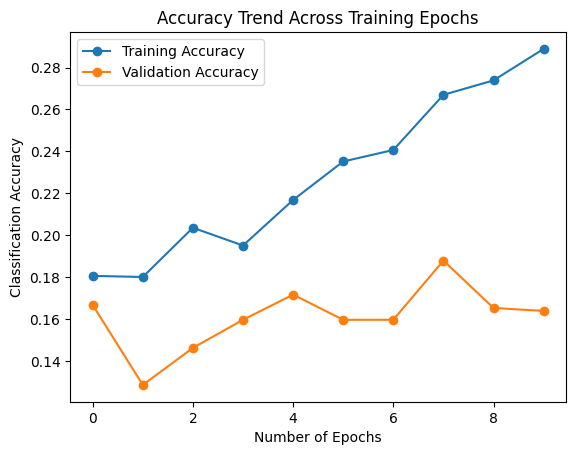

In [35]:
# Visualize training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')

plt.title('Accuracy Trend Across Training Epochs')
plt.xlabel('Number of Epochs')
plt.ylabel('Classification Accuracy')
plt.legend()
plt.show()


In [36]:
!pip3 install gradio

In [37]:
# -----------------------------
# Core numerical and array handling
# -----------------------------
import numpy as np

# -----------------------------
# Deep learning framework
# -----------------------------
import tensorflow as tf

# -----------------------------
# Image loading and preprocessing utilities
# -----------------------------
import cv2
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# -----------------------------
# Web-based interface for model interaction
# -----------------------------
import gradio as gr


In [38]:
# Load the trained CNN model for inference
# Make sure the saved model path is correctly specified
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/Colab Notebooks/SPECIALIZATION MS PROJECTS/Module - 5/Custom_CNN_model.keras'
)


In [39]:
# Define mapping between emotion categories and numerical indices
emotion_labels = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'neutral': 3,
    'sad': 4,
    'happy': 5,
    'surprise': 6
}

# Create reverse lookup to convert model predictions back to emotion names
index_to_emotion = {value: key for key, value in emotion_labels.items()}

index_to_emotion


{0: 'angry',
 1: 'disgust',
 2: 'fear',
 3: 'neutral',
 4: 'sad',
 5: 'happy',
 6: 'surprise'}

In [40]:
def prepare_image(img_pil):
    """Convert a PIL image into a model-ready input tensor."""

    # Standardize image size to match model input
    img = img_pil.resize((48, 48))

    # Convert image to grayscale since the model was trained on single-channel inputs
    img = img.convert('L')

    # Transform the image into a NumPy array
    img_array = img_to_array(img)

    # Expand dimensions to include batch size
    img_array = np.expand_dims(img_array, axis=0)

    # Normalize pixel intensity values
    img_array = img_array / 255.0

    return img_array


In [41]:
# Emotion prediction function used by the Gradio interface
def predict_emotion(image):
    # Prepare the input image for the trained model
    processed_image = prepare_image(image)

    # Generate prediction probabilities
    prediction = model.predict(processed_image)

    # Identify the class index with the highest confidence score
    predicted_class = np.argmax(prediction, axis=1)

    # Map the predicted index to its corresponding emotion label
    predicted_emotion = index_to_emotion.get(predicted_class[0], "Unknown Emotion")

    return predicted_emotion


In [42]:
# Create an interactive Gradio interface for emotion prediction
interface = gr.Interface(
    fn=predict_emotion,                 # Function that performs emotion classification
    inputs=gr.Image(type="pil"),        # Image input accepted as a PIL object
    outputs="text",                     # Display predicted emotion as text
    title="Facial Emotion Recognition System",
    description="Upload a facial image to identify the expressed emotion."
)

# Start the web-based application
interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0e888335a59536bb65.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
